### Important Chain Methods

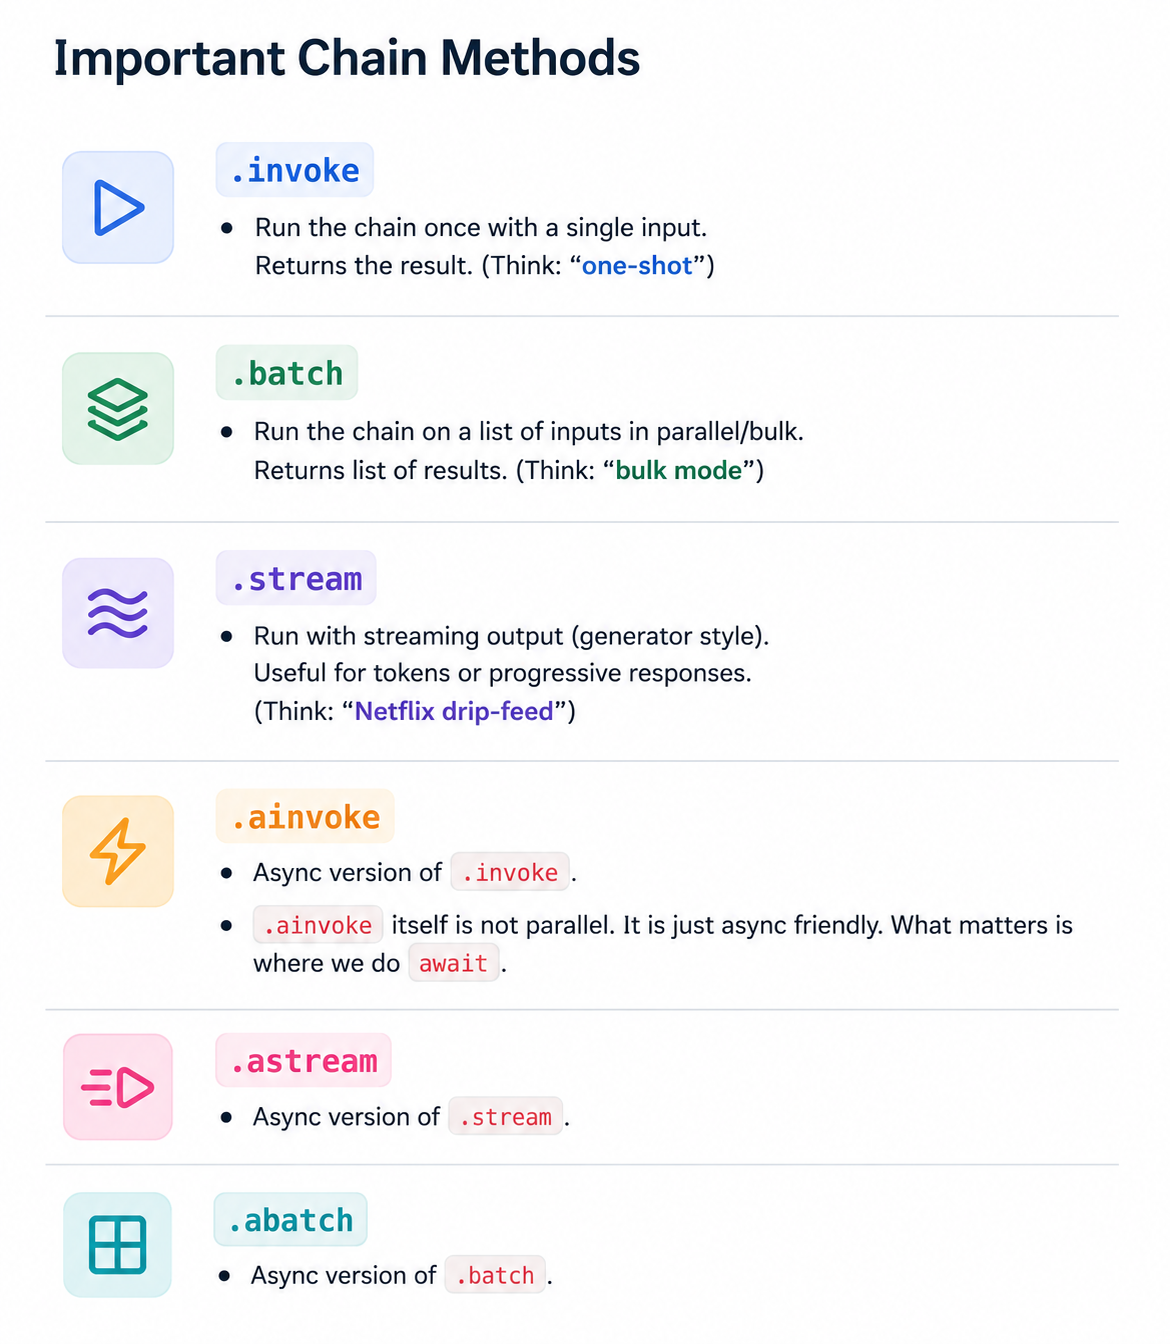

In [7]:
import langchain
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

load_dotenv()

groq_api_key=os.getenv("GROQ_API_KEY")

llm = ChatGroq(
    groq_api_key=groq_api_key,
    model ="openai/gpt-oss-120b" ,
    temperature=0.2
)

llm.invoke("where is pamban located?")  # llm is working properly and returning the output as expected.

AIMessage(content='**Pamban** (also called **Pamban Island** or **Rameswaram Island**) is a small island off the southeastern coast of India.  \n\n| Detail | Information |\n|--------|--------------|\n| **Country** | India |\n| **State** | Tamil\u202fNadu |\n| **District** | Ramanathapuram |\n| **Geographic setting** | Lies in the **Gulf of\u202fMannar**, between the Indian mainland and the island of **Sri\u202fLanka**. |\n| **Nearest major town** | **Rameswaram** (on the same island, about 15\u202fkm north‑west of the town of Pamban). |\n| **Key connection** | Linked to the mainland at **Rameswaram** by the historic **Pamban Bridge** (a rail‑only cantilever bridge) and the newer **Pamban Road Bridge** (a road bridge). |\n| **Coordinates** | Approximately **9.28°\u202fN latitude, 79.30°\u202fE longitude**. |\n| **Time zone** | Indian Standard Time (IST), UTC\u202f+5:30. |\n| **Postal code (PIN)** | 623514 (Pamban). |\n\n### Quick map description\n- **Southwest**: The Indian mainland (Ta

In [8]:
prompt=PromptTemplate.from_template(
    "you are a helpful assistant running output in just plain text. Give me a short bio of {person} in 50 words or less."
)

chain = prompt | llm|StrOutputParser()


## .invoke

In [9]:
result=chain.invoke({"person": "APJ Abdul Kalam"})
print(result)

APJ Abdul Kalam (1931‑2015) was an Indian aerospace scientist and the 11th President of India (2002‑2007). Known as the “Missile Man,” he led development of India's first satellite launch vehicle and ballistic missiles. A beloved educator and author, he inspired millions with his vision for a developed, peaceful nation.


## .batch

In [10]:
persons=[{"person": "C. Joseph Vijay"} , {"person": "Trisha Krishnan"} ,{"person": "Ajith Kumar"}, {"person": "Samantha Akkineni"}]

results=chain.batch(persons)

for i in results:
    print(i ,"\n\n")

C. Joseph Vijay is an Indian film director and screenwriter known for his work in Tamil cinema. Rising from assistant director roles, he debuted with “Maanagaram” (2017), praised for its urban thriller narrative. Vijay continues to craft gritty, character-driven stories in contemporary South Indian film. 


Trisha Krishnan, born May 4 1983 in Chennai, is a prominent Indian actress known for her work in Tamil, Telugu, and Malayalam cinema. Debuting with “Mounam Pesiyadhe” (2002), she gained fame through hits like “Varsham,” “Aayirathil Oruvan,” and “96,” earning multiple awards and a loyal fan base. 


Ajith Kumar, born May 1 1973, is a celebrated Indian actor and motor‑racing enthusiast. Predominantly starring in Tamil cinema, he’s known for versatile roles in films like *Mankatha*, *Viswasam*, and *Valimai*. Nicknamed “Thala,” he balances acting with his passion for competitive racing. 


Samantha Akkineni, born Samantha Ruth Prabhu (April 28 1990), is an Indian actress prominent in T

## .stream

In [20]:
persons=[{"person": "C. Joseph Vijay"}, {"person": "Samantha Akkineni"}]

for p in persons:
    for chunk in chain.stream(p):
        print(chunk,end="", flush=True)
    print()

C. Joseph Vijay is an Indian film director and screenwriter who works primarily in Tamil cinema. Known for his crisp storytelling and visual flair, he gained attention with his debut feature, a critically praised thriller that showcased his talent for tight narratives and engaging characters.
Samantha Akkineni, born Samantha Ruth Prabhu (April 28 1990), is an Indian actress renowned for her work in Telugu and Tamil cinema. Debuting with “Ye Maaya Chesave” (2010), she’s earned multiple Filmfare awards, praised for versatile roles, and is also a philanthropist and entrepreneur.


## .ainvoke

In [24]:
# how invoke take long time currently

r1=chain.invoke({"person": "sundar pichai"})
r2=chain.invoke({"person": "APJ Abdul Kalam"})
r3=chain.invoke({"person": "Steve Jobs"})
print(r1,r2,r3)

Sundar Pichai, born 1972 in Chennai, India, is CEO of Alphabet Inc. and its subsidiary Google. A Stanford-educated engineer, he joined Google in 2004, leading Chrome and Android. Promoted to CEO in 2015, he drives AI, cloud computing, and global tech innovation. A. P. J. Abdul Kalam (1931‑2015) was an Indian aerospace scientist and the 11th President of India. Known as the “Missile Man,” he led development of the Agni and Prithvi rockets. A beloved educator, he inspired millions through his writings and vision for a developed nation. Steve Jobs (1955‑2011) co‑founded Apple Inc., pioneering the personal computer, iPod, iPhone, and iPad. Known for his visionary design sense and charismatic presentations, he transformed technology, entertainment, and retail. After a 1985 departure, he led Pixar to success before returning to Apple, revitalizing it into a global powerhouse.


In [ ]:
# how .ainvoke performe with  .await 

# this also similar to invoke because each step we use awake , so it will take long time to complete the task and this is similar to invoke but it is async and we can use await to get the result.
async def case2():
    r1=await chain.ainvoke({"person": "sundar pichai"})
    r2=await chain.ainvoke({"person": "APJ Abdul Kalam"})
    r3=await chain.ainvoke({"person": "Steve Jobs"})
    print(r1,"\n",r2,"\n",r3)
await case2()

Sundar Pichai, born 1972 in Chennai, India, is CEO of Alphabet Inc. and its subsidiary Google. He joined Google in 2004, leading Chrome and Android development. Promoted to CEO in 2015, he oversees AI, cloud, and hardware initiatives, driving the company’s global growth. 
 Avul Pakir Jainulabdeen Abdul Kalam (1931‑2015), Indian aerospace scientist and 11th President (2002‑2007). Known as the “Missile Man” for developing SLV‑III, Agni and Prithvi missiles. He championed education, authored inspirational books, and inspired youth worldwide. 
 Steve Jobs (1955‑2011) co‑founded Apple Inc., pioneering the personal computer, iPod, iPhone, and iPad. Known for his visionary design sense and charismatic presentations, he transformed technology, music, and mobile communication. After a 1985 departure, he led Pixar to success before returning to Apple, revitalizing it into a global powerhouse.


In [33]:
# making turly parallel processing with python asyncio.gather() and await

import asyncio

async def case3():

    #method 1
    # t1 = asyncio.create_task(chain.ainvoke({"celebrity": "Thalapathy Vijay"}))
    # t2 = asyncio.create_task(chain.ainvoke({"celebrity": "Trisha Krishnan"}))
    # t3 = asyncio.create_task(chain.ainvoke({"celebrity": "Samantha Ruth Prabhu"}))

    # results = await asyncio.gather(t1, t2, t3)


    #method 2
    result = await asyncio.gather(
        chain.ainvoke({"person": "sundar pichai"}),
        chain.ainvoke({"person": "Mark Zuckerberg"}),
        chain.ainvoke({"person": "Elon Musk"}),
    )

    for r in result:
        print(r,"\n")
await case3()


Sundar Pichai, born 1972 in Chennai, India, is CEO of Alphabet Inc. and its subsidiary Google. He joined Google in 2004, leading product development for Chrome and Android. Elevated to CEO in 2015, he drives AI, cloud computing, and global tech innovation. 

Mark Zuckerberg, born May 14 1994, co‑founded Facebook in 2004 while at Harvard. As CEO, he grew it into Meta Platforms, expanding into virtual reality and the metaverse. Known for his tech entrepreneurship, philanthropy via the Chan Zuckerberg Initiative, and influence on global social media. 

Elon Musk, born 1971 in South Africa, is a tech entrepreneur and engineer. He co‑founded Zip2, X.com (later PayPal), and leads SpaceX, Tesla, Neuralink, and The Boring Company. Known for advancing electric vehicles, reusable rockets, and ambitious visions for humanity’s multi‑planet future. 



## Using .abatch instead of python asyncio for simplicity

## .abatch

In [34]:
persons=[{"person": "C. Joseph Vijay"} , {"person": "Trisha Krishnan"} ,{"person": "Ajith Kumar"}, {"person": "Samantha Akkineni"}]

results=await chain.abatch(persons)

for i in results:
    print(i ,"\n\n")

C. Joseph Vijay is an Indian filmmaker active in Tamil cinema, known for socially conscious storytelling and a blend of drama and thriller genres. He emerged with acclaimed short films before directing his first feature, earning praise for nuanced narratives. 


Trisha Krishnan, known mononymously as Trisha, is a prominent Indian actress and model. Born on May 4, 1983 in Chennai, she debuted in Telugu cinema (1999) and rose to fame with Tamil films like *Saamy* (2003). Celebrated for her versatility, she’s a leading South Indian star. 


Ajith Kumar, born May 1 1973, is a celebrated Indian actor and motor‑racing enthusiast. Primarily known for his work in Tamil cinema, he debuted with “Amaravathi” (1993) and rose to fame through hits like “Mankatha,” “Viswasam,” and “Valimai.” He’s also a philanthropist. 


Samantha Akkineni, born Samantha Ruth Prabhu (April 28 1990), is an Indian actress renowned for her work in Telugu and Tamil cinema. Debuting with “Ye Maaya Chesave” (2010), she ear

## .astream

In [38]:
persons=[{"person": "C. Joseph Vijay"}, {"person": "Samantha Akkineni"}]

for p in persons:
    async for chunk in chain.astream(p):
        print(chunk,end="", flush=True)
    print()

C. Joseph Vijay is an Indian film director and screenwriter, active in Tamil cinema, noted for his socially relevant narratives and award‑winning films.
Samantha Akkineni, Indian actress and philanthropist, debuted in 2009 with “Ye Maaya Chesave.” Known for versatile roles in Telugu and Tamil cinema, she has earned multiple awards. She co‑founded the Samantha Akkineni Foundation, supporting education and health initiatives.


## .astream_events

In [39]:
persons=[{"person": "C. Joseph Vijay"}, {"person": "Samantha Akkineni"}]

for p in persons:
    async for chunk in chain.astream_events(p):
        print(chunk,end="", flush=True)
    print()

{'event': 'on_chain_start', 'data': {'input': {'person': 'C. Joseph Vijay'}}, 'name': 'RunnableSequence', 'tags': [], 'run_id': '01a0539f-14d8-73c3-92af-e5d3f87426f4', 'metadata': {}, 'parent_ids': []}{'event': 'on_prompt_start', 'data': {'input': {'person': 'C. Joseph Vijay'}}, 'name': 'PromptTemplate', 'tags': ['seq:step:1'], 'run_id': '01a0539f-14db-76e2-9900-e120dd3054d4', 'metadata': {}, 'parent_ids': ['01a0539f-14d8-73c3-92af-e5d3f87426f4']}{'event': 'on_prompt_end', 'data': {'output': StringPromptValue(text='you are a helpful assistant running output in just plain text. Give me a short bio of C. Joseph Vijay in 50 words or less.'), 'input': {'person': 'C. Joseph Vijay'}}, 'run_id': '01a0539f-14db-76e2-9900-e120dd3054d4', 'name': 'PromptTemplate', 'tags': ['seq:step:1'], 'metadata': {}, 'parent_ids': ['01a0539f-14d8-73c3-92af-e5d3f87426f4']}{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[HumanMessage(content='you are a helpful assistant running output in just pl

### Difference btw .stream and .astream

In [51]:
import asyncio

persons = [{"person":"Trisha Krishnan"}, {"person":"Ajith Kumar"}, {"person":"Samantha Ruth Prabhu"}]

async def background_timer():
    for i in range(5):
        await asyncio.sleep(1)
        print(f"[Timer] {i+1} seconds passed")

async def run_streams():
    timer_task = asyncio.create_task(background_timer())
    
    for person in persons:
        chunks = chain.astream(person)
        async for chunk in chunks:
            print(chunk, end="")
        print("\n--- Done ---")
        
    await timer_task

await run_streams()


Trisha Krishnan, born May 30 1983 in Chennai, is a leading Indian actress known for her work in Tamil, Telugu, and Hindi cinema. Debuting with “Mounam Pesiyadhe” (2002), she gained fame through hits like “Varsham,” “Aayirathil Oruvan,” and “96,” earning multiple awards and a massive fan base.
--- Done ---
[Timer] 1 seconds passed
Ajith Kumar, born May 1 1973, is a celebrated Indian actor and motor‑racing enthusiast primarily known for his work in Tamil cinema. Debuting with “Amaravathi” (1993), he rose to fame through hits like “Mankatha,” “Viswasam,” and “Valimai,” earning the nickname “Thala.”
--- Done ---
[Timer] 2 seconds passed
Samantha Ruth Prabhu (born 28 April 1987) is an Indian actress prominent in Telugu and Tamil cinema. She debuted in 2010 with “Ye Maaya Chesave,” earned multiple awards, starred in hits like “Eega” and “Mahanati,” and serves as a leading brand ambassador.
--- Done ---
[Timer] 3 seconds passed
[Timer] 4 seconds passed
[Timer] 5 seconds passed
